<a href="https://colab.research.google.com/github/RixzFahad/Data-Visualization/blob/main/Fahad_data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Topic: Data Visualization + Data Cleaning + NumPy Operations***

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load inbuilt dataset
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


***Q1. Display first 10 rows and dataset info.***

**Task:**


*  Show first 10 rows
*  Print dataset shape
*  Show missing values

**Intuition:**

**observe:**


1.   Missing values in age, deck, embark_town
2.   Mixture of categorical and numerical columns

In [5]:
#Showing First 10 Row's
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [6]:
#Print DataSet Shape
df.shape

(891, 15)

In [7]:
#Show Missing Value's
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


***Q2.Find survival rate percentage.***

**Intuition:** Value will be around 38%.

This tells survival was difficult — class & gender might influence survival

In [8]:
#Find Survival Rate Percentage
df.value_counts("survived")
#getting Percentage OF Total
df.value_counts("survived", normalize=True)


,proportion
survived,
0,0.616162
1,0.383838


***Q3. Fill missing Age values with mean.***

**Intuition:** Age is important numerical feature. Replacing with mean keeps distribution stable.

In [9]:
#Fill Missing Age Values With Means
df.isnull().sum()
df["age"].fillna(df["age"].mean(), inplace=True)
df.isnull().sum()


/tmp/ipython-input-647/1747866283.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].mean(), inplace=True)


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [10]:
#Checking For Age Null Values
df.isnull().sum()

# Now IT's Zero Filled With Mean

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


***Q4. Drop column with too many missing values.***

*Intuition:*

deck has too many missing values → not reliable for analysis.




In [11]:
#Droping Cols With Too Many Missing Values--
#First Check In Which Col's I Have Many Missing Value's
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [12]:
#So In Deck Col I having Many Missing Value: Which Also Not UseFull For Analysis
df.drop("deck", axis=1, inplace=True)
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


***Q5. Convert categorical column to numerical using NumPy.***

*Convert sex column:*


*   male → 1
*  female → 0

**Intuition:**

Machine learning models need numerical data.

In [13]:
#Convertiing Categorical Col Sexx Into Numerical Col's
df.replace({"sex": {"male": 1, "female": 0}}, inplace=True)
df.head()

/tmp/ipython-input-647/3149683247.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"sex": {"male": 1, "female": 0}}, inplace=True)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


***Q6. Create new feature using NumPy.***

Create family_size = sibsp + parch

*Intuition:*

Passengers traveling with family might have better survival chances.

In [14]:
#Creating New Features Using Numpy.
df["family_size"] = df["sibsp"] + df["parch"]
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,1
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,1
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,1
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,0


***Q7. Line Plot – Survival rate by Passenger Class***

**Intuition:**



*  1st class passengers had higher survival.
*  Shows social-economic impact.


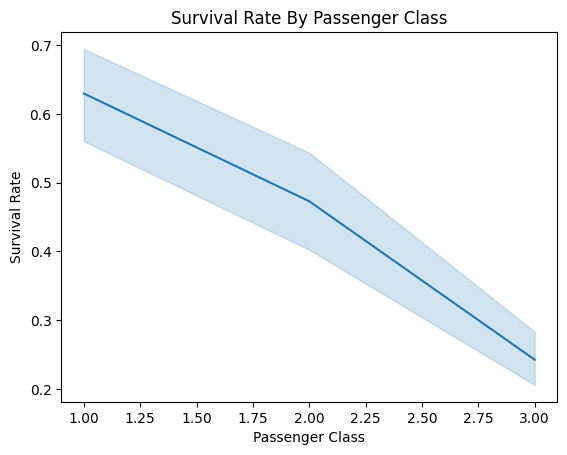

In [15]:
#Survival Rate By passenger Class -
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x="pclass", y="survived", data=df)
plt.title("Survival Rate By Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


***Q8. Scatter Plot – Age vs Fare***

**Intuition:**

Higher fare passengers more likely survived.

Age does not strongly correlate with fare.

Text(0.5, 1.0, 'Age Vs Fare')

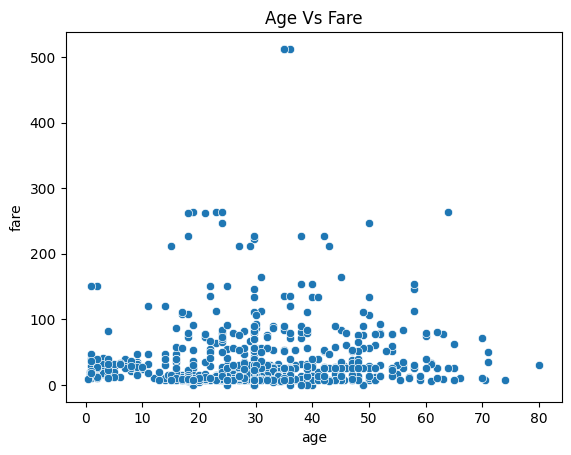

In [16]:
#Scatter Plot Age Vs Fare
sns.scatterplot(x="age", y="fare", data=df)
plt.title("Age Vs Fare")

***Q9. Boxplot – Age Distribution by Survival***

**Intuition:**

Children had higher survival rate.

Outliers present in older ages.

Text(0.5, 1.0, 'Age Distribution By Survival')

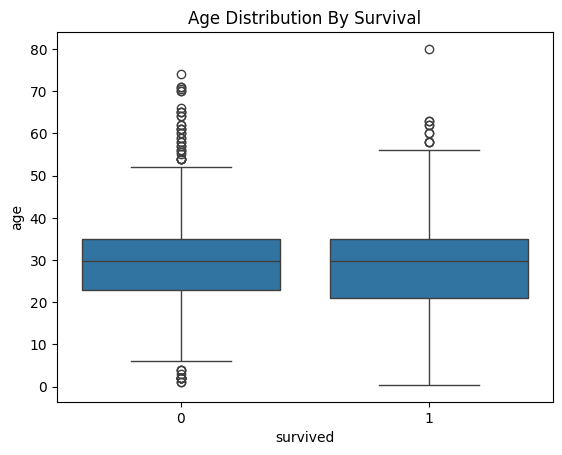

In [17]:
sns.boxplot(x="survived", y="age", data=df)
plt.title("Age Distribution By Survival")

***Q10. Histplot – Age Distribution***

**Intuition:**

Most passengers between 20–40.

Slight right skew.

Text(0.5, 1.0, 'Age Distribution')

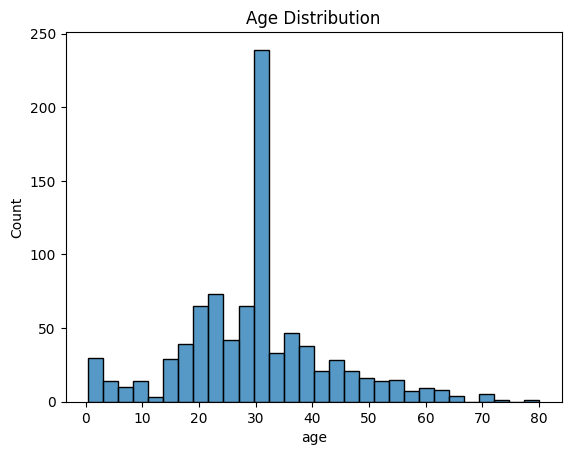

In [18]:
sns.histplot(x="age", data=df)
plt.title("Age Distribution")
#there more than 250 people which have age 25-30

***Q11. Displot – Fare Distribution***

**Intuition:**

Highly right-skewed.

Few passengers paid very high fares.

Text(0.5, 1.0, 'Fare Distribution')

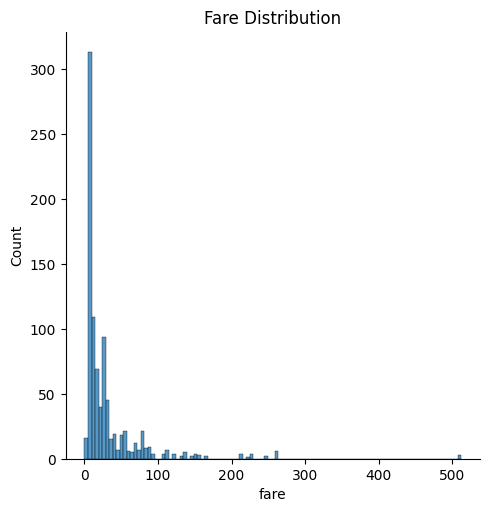

In [19]:
sns.displot(x="fare", data=df)
plt.title("Fare Distribution")

***Q12. Catplot – Survival by Gender***

**Intuition:**

Females had much higher survival rate.

Strong gender impact.

Text(0.5, 1.0, 'Survival By Gender')

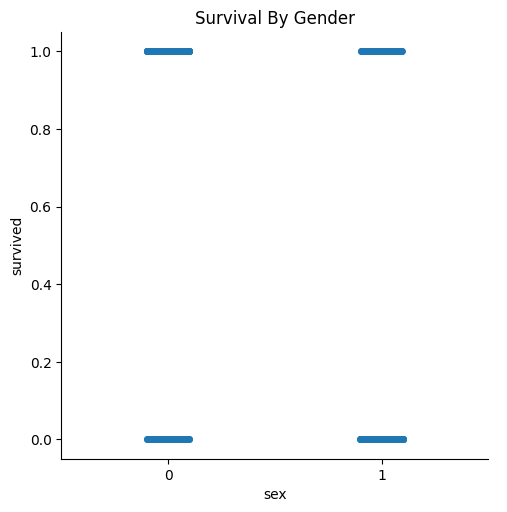

In [20]:
sns.catplot(x="sex", y="survived", data=df)
plt.title("Survival By Gender")


***Q13. Find average fare using NumPy.***



In [23]:
#Avg Of Fare
np.mean(df["fare"])


np.float64(32.204207968574636)

***Q14. Find standard deviation of age.***

In [24]:
#STd Deviation Of Age
np.std(df["age"])


12.994716872789033

***Q15. Create Age Category using NumPy.***




*  If age < 18 → Child
*  Else → Adult




In [25]:
#Age Category
df["age_category"] = np.where(df["age"] < 18, "Child", "Adult")

In [27]:
#Checking The New Columns
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,age_category
0,0,3,1,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False,1,Adult
1,1,1,0,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,1,Adult
2,1,3,0,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0,Adult
3,1,1,0,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False,1,Adult
4,0,3,1,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True,0,Adult
5,0,3,1,29.699118,0,0,8.4583,Q,Third,man,True,Queenstown,no,True,0,Adult
6,0,1,1,54.000000,0,0,51.8625,S,First,man,True,Southampton,no,True,0,Adult
7,0,3,1,2.000000,3,1,21.0750,S,Third,child,False,Southampton,no,False,4,Child
8,1,3,0,27.000000,0,2,11.1333,S,Third,woman,False,Southampton,yes,False,2,Adult
9,1,2,0,14.000000,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False,1,Child


# ***Is age strongly affecting survival?***

***When the Titanic was sinking, there weren’t enough lifeboats for everyone.***

So the crew followed a common rule at that time: “women and children first.”

This meant:

*  There were only limited lifeboats.
*  Women were allowed to get on first.
* Children were given priority to stay safe.
*  Many adult men had to wait, and some never got a chance to board.


# ***What happens if we don’t clean missing values?***

***Many ML models like Logistic Regression, SVM, etc. cannot handle null values***.

#***Why convert categorical data into numerical?***

***Machine Learning Models Define A Numerical Data Easily. So We Need To Convert Category Col To Numerical Cols***